In [1]:
import pandas as pd 
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import napari
import os

import shutil
from glob import glob

In [2]:
%load_ext autoreload
%autoreload 2

import sys 
sys.path.append('../src')

In [4]:
# img_dir = '/Volumes/Lord/LabUsers/Dmytro/20260717T120225_pA_Activin_D4_48hr/'
# channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']

img_dir = '/Volumes/Lord/LabUsers/Dmytro/20260521T171725_pA-BMP4_G3_44hr_induction/'
channel_names = ['T', 'BMP4', 'CDX2', 'Hoechst']
well = 'W0001'

experiment = os.path.dirname(img_dir).split('/')[-1]
img_name = f'{experiment}_{well}'

well_paths = glob(img_dir + f'Projection/{well}*')
well_dest = f'../data/downloads/{experiment}'
save_dir = '../data/stitched/'
os.makedirs(well_dest, exist_ok=True)

for path in well_paths:
    dest_name = os.path.join(well_dest, os.path.basename(path))
    shutil.copy(path, dest_name)

well_imgs = glob(well_dest + f'/{well}*')
well_imgs

['../data/downloads/20260521T171725_pA-BMP4_G3_44hr_induction/W0001F0002T0001Z000C4.tif',
 '../data/downloads/20260521T171725_pA-BMP4_G3_44hr_induction/W0001F0002T0001Z000C3.tif',
 '../data/downloads/20260521T171725_pA-BMP4_G3_44hr_induction/W0001F0002T0001Z000C2.tif',
 '../data/downloads/20260521T171725_pA-BMP4_G3_44hr_induction/W0001F0002T0001Z000C1.tif',
 '../data/downloads/20260521T171725_pA-BMP4_G3_44hr_induction/W0001F0001T0001Z000C4.tif',
 '../data/downloads/20260521T171725_pA-BMP4_G3_44hr_induction/W0001F0001T0001Z000C2.tif',
 '../data/downloads/20260521T171725_pA-BMP4_G3_44hr_induction/W0001F0001T0001Z000C3.tif',
 '../data/downloads/20260521T171725_pA-BMP4_G3_44hr_induction/W0001F0001T0001Z000C1.tif']

### Stitch and segment

In [5]:
import re
from tools.restitch_fovs import feather_blend

FOV_RE = re.compile(r'F(\d+)T\d+Z(\d+)C(\d+)')

def read_center_position(path):
    """Stage position (x_um, y_um, xy_res_um) from the CQ1 MakerNote XML."""
    with tiff.TiffFile(path) as tf:
        note = tf.pages[0].tags[37500].value
    x = float(re.search(r'<CenterPositionX>([\-0-9.]+)</CenterPositionX>', note).group(1))
    y = float(re.search(r'<CenterPositionY>([\-0-9.]+)</CenterPositionY>', note).group(1))
    xy_res = float(re.search(r'<XYResolution_um>([\-0-9.]+)</XYResolution_um>', note).group(1))
    return x, y, xy_res

In [6]:
# CenterPositionX/Y in the MakerNote are in units of 0.1um, not um
# (confirmed by cross-correlating the true overlap between neighboring FOVs).
CENTER_POS_UNIT_UM = 0.1

by_channel = {}
for path in well_imgs:
    match = FOV_RE.search(os.path.basename(path))
    if match is None:
        continue  # skip non-FOV files, e.g. previously saved stitched/cropped outputs
    fov, z, ch = match.groups()
    by_channel.setdefault(int(ch), {})[int(fov)] = path

# order FOVs consistently (by FOV index) across all channels
fov_ids = sorted(next(iter(by_channel.values())).keys())
fov_paths_by_channel = {ch: [paths[f] for f in fov_ids] for ch, paths in sorted(by_channel.items())}


In [7]:
def stitch_fovs(fov_paths_by_channel, blend_width=100):
    """Stitch FOVs placed at arbitrary (non-grid) stage positions into one
    per-channel mosaic, using CQ1 stage-position metadata for tile placement
    and `feather_blend` (from tools.restitch_fovs) to blend the overlaps."""
    ref_paths = next(iter(fov_paths_by_channel.values()))
    positions = [read_center_position(p) for p in ref_paths]
    x0, y0, xy_res = positions[0]
    offsets = [
        ((y - y0) * CENTER_POS_UNIT_UM / xy_res, (x - x0) * CENTER_POS_UNIT_UM / xy_res)
        for x, y, xy_res in positions
    ]

    fov_size = tiff.imread(ref_paths[0]).shape[0]
    min_y = min(dy for dy, dx in offsets)
    min_x = min(dx for dy, dx in offsets)
    canvas_h = int(round(max(dy for dy, dx in offsets) - min_y)) + fov_size
    canvas_w = int(round(max(dx for dy, dx in offsets) - min_x)) + fov_size

    stitched = {}
    for ch, paths in fov_paths_by_channel.items():
        canvas = np.zeros((canvas_h, canvas_w), dtype=np.float32)
        weight = np.zeros((canvas_h, canvas_w), dtype=np.float32)
        tile = None
        for path, (dy, dx) in zip(paths, offsets):
            tile = tiff.imread(path)
            y0i = int(round(dy - min_y))
            x0i = int(round(dx - min_x))
            feather_blend(canvas, weight, tile, y0i, x0i, blend_width)
        weight[weight == 0] = 1
        stitched[ch] = (canvas / weight).astype(tile.dtype)
    return stitched


stitched = stitch_fovs(fov_paths_by_channel)
{ch: img.shape for ch, img in stitched.items()}

{1: (2445, 2000), 2: (2445, 2000), 3: (2445, 2000), 4: (2445, 2000)}

In [8]:
stitched_stack = np.stack([stitched[ch] for ch in sorted(stitched)], axis=0)
stitched_stack.shape

(4, 2445, 2000)

In [9]:
def largest_square_bbox(valid_mask):
    """(y0, x0, side) of the largest all-valid axis-aligned square in a bool mask."""
    h, w = valid_mask.shape
    integral = np.zeros((h + 1, w + 1), dtype=np.int64)
    integral[1:, 1:] = valid_mask.cumsum(0).cumsum(1)

    def window_sums(k):
        return integral[k:, k:] - integral[:-k, k:] - integral[k:, :-k] + integral[:-k, :-k]

    lo, hi = 1, min(h, w)
    best_k, best_pos = 0, None
    while lo <= hi:
        mid = (lo + hi) // 2
        hits = np.argwhere(window_sums(mid) == mid * mid)
        if len(hits) > 0:
            best_k, best_pos = mid, hits[len(hits) // 2]
            lo = mid + 1
        else:
            hi = mid - 1
    y0, x0 = best_pos
    return int(y0), int(x0), int(best_k)

# a pixel is only black in every channel where feather_blend zeroed out an
# unsupported tile edge -- real signal never hits 0 in all 4 channels at once.
valid_mask = ~(stitched_stack == 0).all(axis=0)
y0, x0, side = largest_square_bbox(valid_mask)
print(f'Largest black-free square: {side}x{side} at (y={y0}, x={x0})')

cropped_stack = stitched_stack[:, y0:y0 + side, x0:x0 + side]

cropped_path = os.path.join(save_dir, f'{img_name}.tif')
tiff.imwrite(cropped_path, cropped_stack, metadata={'axes': 'CYX', 'channel_names': channel_names})
print(f'Saved {cropped_path}  shape={cropped_stack.shape}')

Largest black-free square: 1998x1998 at (y=224, x=1)
Saved ../data/stitched/20260521T171725_pA-BMP4_G3_44hr_induction_W0001.tif  shape=(4, 1998, 1998)


In [10]:
viewer = napari.Viewer()
_ = viewer.add_image(
    cropped_stack,
    channel_axis=0,
    name=channel_names,
    colormap=['magenta', 'red', 'green', 'blue'],
    blending='additive'
)

In [11]:
from cellpose import models

model = models.CellposeModel(
    model_type='nuclei',
    gpu=True
)

masks, flows, styles = model.eval(
    cropped_stack,
    channels=[4, 0],
    channel_axis=0,
    diameter=None, 
    cellprob_threshold=-15,
    flow_threshold=0.9,
    normalize={"tile_norm_blocksize": 100}
)

_ = viewer.add_image(masks, name='Cellpose Masks')

/opt/anaconda3/envs/latte/lib/python3.11/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


In [12]:
np.save(os.path.join(save_dir, f'{img_name}.npy'), masks)
cropped_stack.shape, masks.shape

((4, 1998, 1998), (1998, 1998))

### Create cell features and QC

In [13]:
out = tiff.imread(os.path.join(save_dir, f'{img_name}.tif'))
masks = np.load(os.path.join(save_dir, f'{img_name}.npy'))
out.shape, masks.shape

((4, 1998, 1998), (1998, 1998))

In [14]:
# viewer = napari.Viewer()
# _ = viewer.add_image(
#     out,
#     channel_axis=0,
#     name=channel_names,
#     colormap=['blue', 'green', 'red', 'magenta'],
#     blending='additive'
# )

In [15]:
masks.max()

np.uint16(8460)

In [16]:
from tools.qc import plot_flagged_crops, plot_feature_histograms, plot_density_map, flag_outlier_bins, crop_region
from tools.features import extract_cell_features, filter_cells

cell_df = extract_cell_features(out, masks, channel_names=channel_names)
cell_df.to_parquet(f'../data/stitched/{img_name}_features.parquet')

print(cell_df.shape)
cell_df.head()

(8460, 18)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,orientation,equivalent_diameter,circularity,aspect_ratio,T_mean,BMP4_mean,CDX2_mean,Hoechst_mean
cell_id,,,,,,,,,,,,,,,,,,
1,12.914561,28.009627,831.0,108.769553,105.801519,0.488736,0.974209,0.842799,35.141412,30.658481,-1.530655,32.527866,0.932883,1.146222,120.766546,117.476534,222.641396,623.598075
2,3.857143,52.584416,154.0,48.142136,48.323124,0.831432,0.980892,0.810526,19.251009,10.696384,1.496365,14.002817,0.828744,1.799768,122.350649,117.551948,211.422078,586.337662
3,8.926136,88.539773,352.0,72.526912,71.441341,0.774091,0.953930,0.698413,26.922827,17.044157,0.847373,21.170270,0.866669,1.579593,123.528409,118.522727,226.752841,683.954545
4,3.100000,99.485714,70.0,31.313708,32.368774,0.548503,0.933333,0.707071,10.854123,9.075660,1.132402,9.440697,0.839567,1.195960,124.285714,118.500000,242.357143,684.400000
5,8.784916,114.567039,358.0,73.112698,71.996702,0.763837,0.949602,0.724696,26.873744,17.344550,1.146581,21.349936,0.867896,1.549406,132.175978,118.544693,261.209497,696.494413


flag
low_density     3
high_density    3
Name: count, dtype: int64


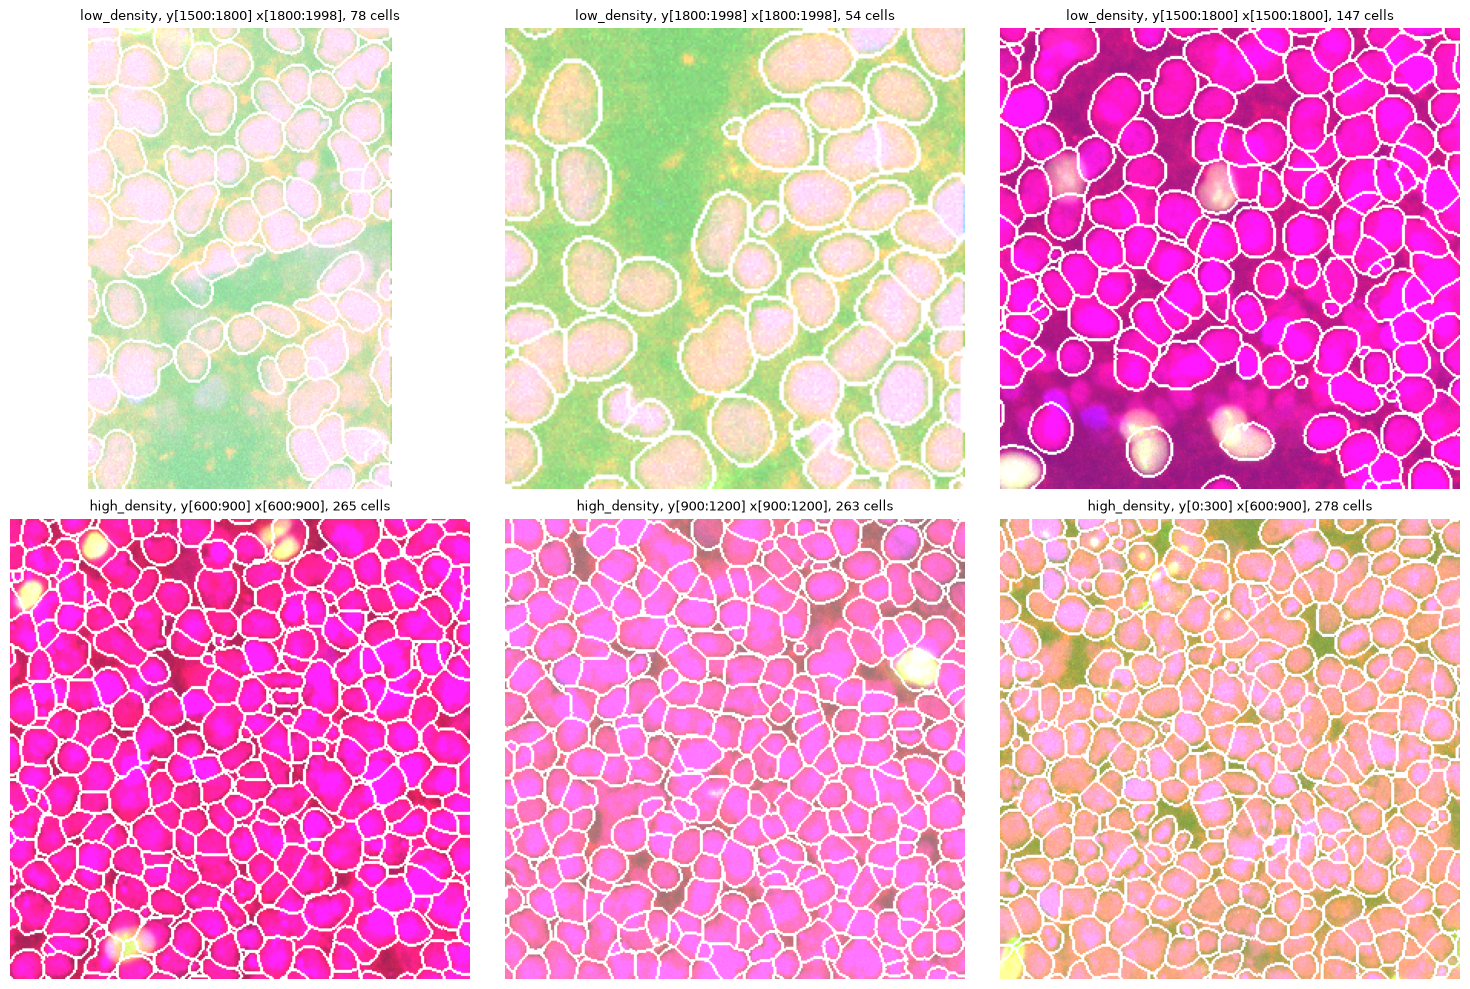

In [17]:
# Matplotlib grid of the worst-flagged regions -- no napari here on purpose: a second
# napari.Viewer() alongside the whole-mosaic one (already holding the full image +
# a 100k+-label mask, plus whatever GPU memory cellpose left resident) is what was
# crashing the kernel. This is also just better for paging through several flagged
# regions at once instead of one Viewer per row -- increase `n` to see more.

# Bins whose cell density (normalized by actual pixel area, so edge bins aren't
# falsely flagged) is a low/high outlier vs. the rest of the image -- worst first.
flagged = flag_outlier_bins(cell_df, out.shape[1:], bin_size=300)
print(flagged['flag'].value_counts())
flagged.head(10)

plot_flagged_crops(out, masks, flagged, colors=['blue', 'green', 'red', 'magenta'], n=6);

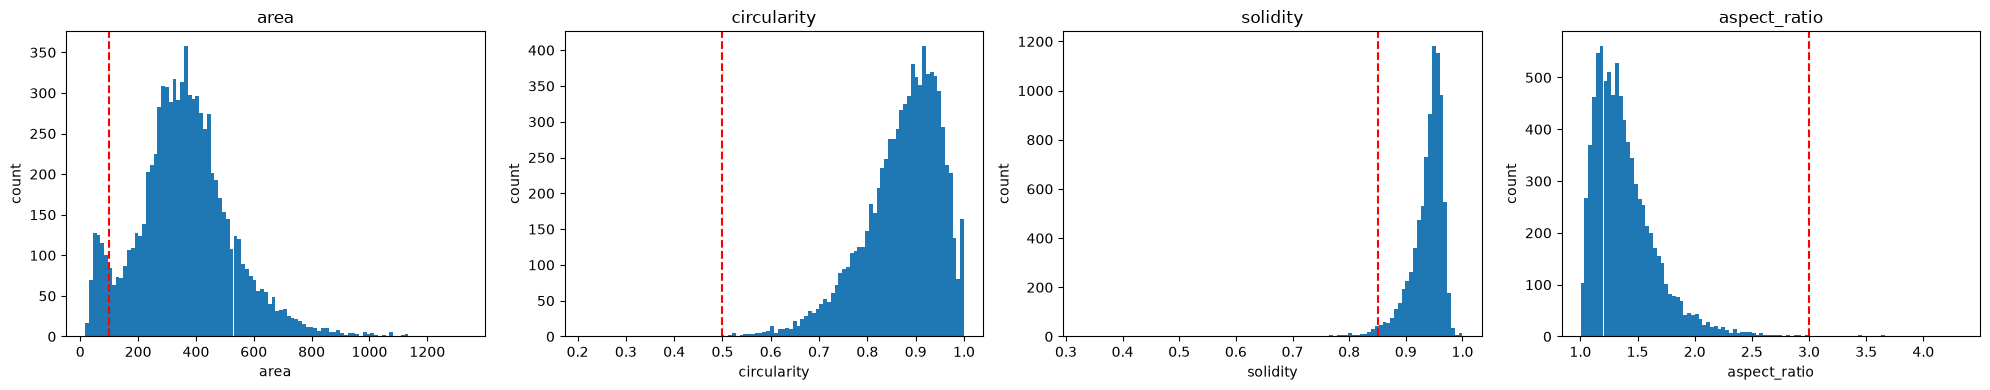

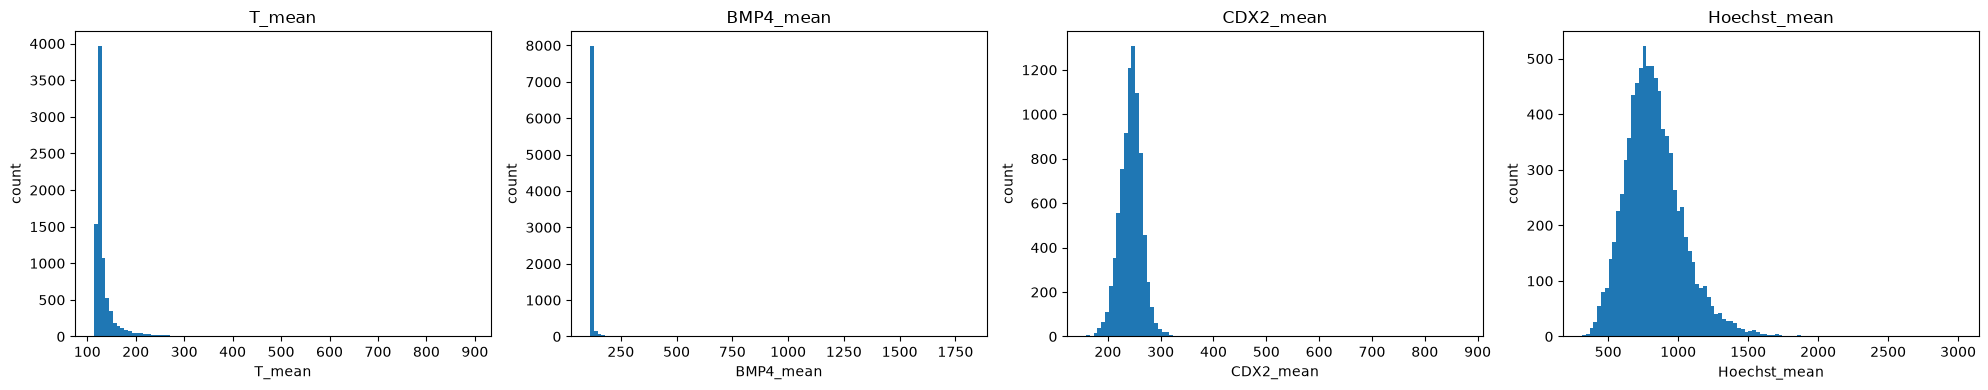

In [18]:
# Spikes near 0 = noise/fragments; a heavy right tail = merged/under-segmented blobs;
# low circularity/solidity + high aspect_ratio = thin, concave "gap between cells"
# artifacts (a crescent-shaped sliver along a cell-cell boundary getting its own label).
# view_thresholds below are starting points -- eyeball where your data actually
# separates into two populations and adjust before filtering.

if_channels = [f'{c}_mean' for c in channel_names]
_ = plot_feature_histograms(
    cell_df,
    ['area', 'circularity', 'solidity', 'aspect_ratio'],
    view_thresholds={'area': 100, 'circularity': 0.5, 'solidity': 0.85, 'aspect_ratio': 3.0}
)
_ = plot_feature_histograms(
    cell_df,
    if_channels,
)

In [19]:
# filtered_df = filter_cells(
#     cell_df,
#     # min_thresholds={'area': 100, 'circularity': 0.5, 'solidity': 0.85},
#     # max_thresholds={'aspect_ratio': 3.0},
# )
# filtered_df.shape[0], f"{100 * filtered_df.shape[0] / cell_df.shape[0]:.1f}% kept"

filtered_df = cell_df

In [20]:
# filtered_masks = np.where(np.isin(masks, filtered_df.index), masks, 0)
# _ = viewer.add_image(filtered_masks, name='Filtered Cellpose Masks')
# np.save(f'../data/stitched/{img_name}.npy', masks)

filtered_masks = masks

In [21]:
# # flagged = flag_outlier_bins(filtered_df, out.shape[1:], bin_size=300)
# # print(flagged['flag'].value_counts())
# # flagged.head(10)

# plot_flagged_crops(out, filtered_masks, flagged, colors=['blue', 'green', 'red', 'magenta'], n=6);

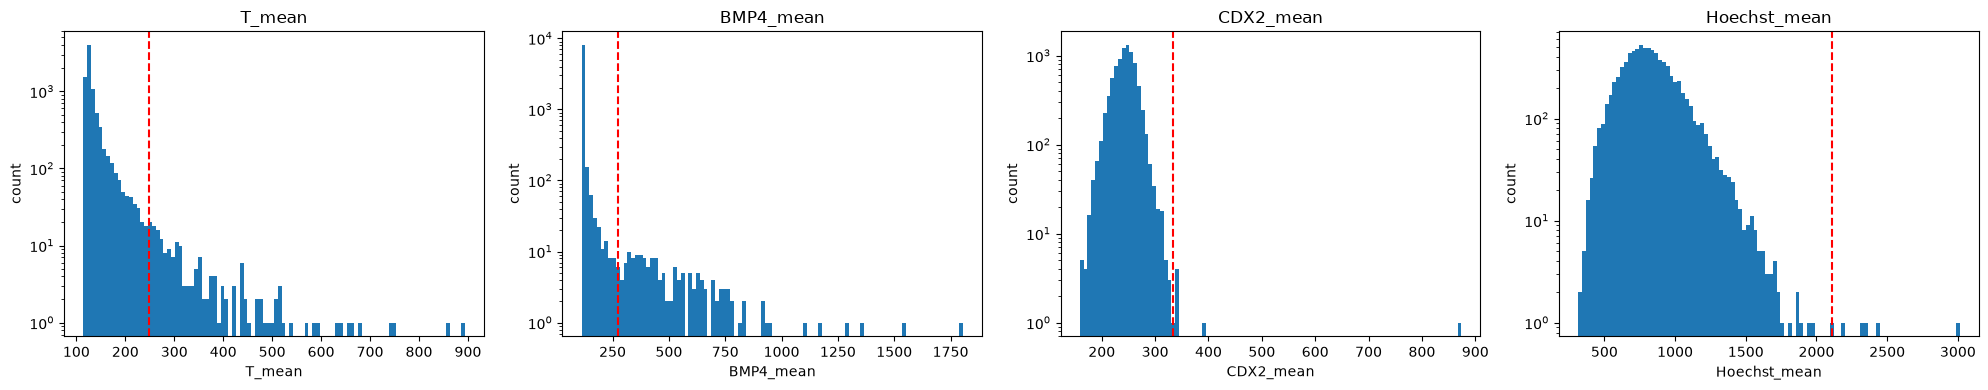

In [22]:
from tools.qc import get_bimodal_threshold
threshes = {k: get_bimodal_threshold(filtered_df, k) for k in if_channels}

_ = plot_feature_histograms(
    cell_df,
    if_channels,
    view_thresholds=threshes,
    log_scale=True
)

In [23]:
immf_masks = {}
for immf in if_channels:
    pos_name = immf.replace('_mean', '+')
    filtered_df[pos_name] = filtered_df[immf] > threshes[immf]
    pos_cells = filtered_df[filtered_df[pos_name] == True].index
    immf_masks[pos_name] = np.where(np.isin(filtered_masks, pos_cells), filtered_masks, 0)

immf_masks.keys()

dict_keys(['T+', 'BMP4+', 'CDX2+', 'Hoechst+'])

In [24]:
filtered_df['Hoechst+'] = True # manually do this since it was pretty good segmentation

for immf_name, mask in immf_masks.items():
    _ = viewer.add_image(mask, name=immf_name, colormap='turbo')

In [25]:
tmp = pd.concat([filtered_df[immf].value_counts() for immf in immf_masks.keys()], axis=1)
tmp.columns = immf_masks.keys()
tmp

,T+,BMP4+,CDX2+,Hoechst+
False,8276,8301,8454,NaN
True,184,159,6,8460.0


In [26]:
filtered_df.to_parquet(f'../data/stitched/{img_name}_features.parquet')

In [27]:
# viewer.close()

In [28]:
masks.shape

(1998, 1998)